## 📦 Import Dependencies

In [2]:
import sys
sys.path.insert(0, '/home/unitree/Desktop/LZH/umi2lerobot/das-datakit')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from IPython.display import display, HTML, Video

from utils.mcaploader import McapLoader

## 📂 加载 MCAP 文件

In [3]:
# 设置 MCAP 文件路径
mcap_file = "/mnt/raid0/UMI2Lerobot/rawData/10Kh-RealOmin-OpenData/Cooking_and_Kitchen_Clean/clean_container/00001/00001.mcap"

# 加载 MCAP 文件
bag = McapLoader(mcap_file)

# 显示基本信息
print(f"MCAP 文件: {Path(mcap_file).name}")
print(f"时长: {(bag.msg_end_time - bag.msg_start_time) / 1e9:.2f} 秒")
print(f"\n可用 Topics ({len(bag.all_topic_names)}):\n")
for topic in bag.all_topic_names:
    print(f"  - {topic}")

MCAP 文件: 00001.mcap
时长: 42.66 秒

可用 Topics (14):

  - /robot0/sensor/imu
  - /robot0/sensor/camera0/camera_info
  - /robot0/sensor/magnetic_encoder
  - /robot1/sensor/camera0/camera_info
  - /robot1/sensor/imu
  - /robot1/sensor/magnetic_encoder
  - /robot0/sensor/camera0/compressed
  - /robot1/sensor/camera0/compressed
  - /robot1/vio/eef_pose
  - /robot1/sim/robot_info
  - /robot0/vio/eef_pose
  - /robot0/sim/robot_info
  - /robot1/system_info
  - /robot0/system_info


## 🎥 加载数据

In [3]:
# 获取数据
camera0_data = bag.get_topic_data("/robot0/sensor/camera0/compressed")
camera1_data = bag.get_topic_data("/robot1/sensor/camera0/compressed")
vio0_data = bag.get_topic_data("/robot0/vio/eef_pose")
vio1_data = bag.get_topic_data("/robot1/vio/eef_pose")
imu0_data = bag.get_topic_data("/robot0/sensor/imu")
imu1_data = bag.get_topic_data("/robot1/sensor/imu")
encoder0_data = bag.get_topic_data("/robot0/sensor/magnetic_encoder")
encoder1_data = bag.get_topic_data("/robot1/sensor/magnetic_encoder")

print(f"Robot0 相机: {len(camera0_data)} 帧")
print(f"Robot1 相机: {len(camera1_data)} 帧")
print(f"Robot0 VIO: {len(vio0_data)} 帧")
print(f"Robot1 VIO: {len(vio1_data)} 帧")

Robot0 相机: 2396 帧
Robot1 相机: 2395 帧
Robot0 VIO: 2389 帧
Robot1 VIO: 2390 帧


## 🌳 MCAP 数据结构层级展示

In [29]:
# 获取数据维度信息
bag_name = Path(bag.get_bag_path()).name
duration = (bag.msg_end_time - bag.msg_start_time) / 1e9

n_cam0 = len(camera0_data) if camera0_data else 0
n_cam1 = len(camera1_data) if camera1_data else 0
n_vio0 = len(vio0_data) if vio0_data else 0
n_vio1 = len(vio1_data) if vio1_data else 0
n_imu0 = len(imu0_data) if imu0_data else 0
n_imu1 = len(imu1_data) if imu1_data else 0
n_enc0 = len(encoder0_data) if encoder0_data else 0
n_enc1 = len(encoder1_data) if encoder1_data else 0

# 获取单帧数据维度
img_h, img_w, img_c = camera0_data[0]["decode_data"].shape if camera0_data else (0,0,0)
img_dtype = camera0_data[0]["decode_data"].dtype if camera0_data else "N/A"
vio_dim = vio0_data[0]["decode_data"].shape[0] if vio0_data else 0
imu_dim = imu0_data[0]["decode_data"].shape[0] if imu0_data else 0
enc_dim = encoder0_data[0]["decode_data"].shape[0] if encoder0_data else 0

# 从 bag.topic_frequency_info 获取真实频率
freq_cam0 = bag.topic_frequency_info.get("/robot0/sensor/camera0/compressed", 0)
freq_cam1 = bag.topic_frequency_info.get("/robot1/sensor/camera0/compressed", 0)
freq_imu0 = bag.topic_frequency_info.get("/robot0/sensor/imu", 0)
freq_imu1 = bag.topic_frequency_info.get("/robot1/sensor/imu", 0)
freq_enc0 = bag.topic_frequency_info.get("/robot0/sensor/magnetic_encoder", 0)
freq_enc1 = bag.topic_frequency_info.get("/robot1/sensor/magnetic_encoder", 0)
freq_vio0 = bag.topic_frequency_info.get("/robot0/vio/eef_pose", 0)
freq_vio1 = bag.topic_frequency_info.get("/robot1/vio/eef_pose", 0)

tree = f"""
📁 {bag_name}                                    # 时长: {duration:.1f}s
│
├── 📁 robot0/                                       # 机器人0 (主手/操作者)
│   ├── 📁 sensor/
│   │   ├── 📷 camera0/compressed    ({n_cam0}, {img_h}, {img_w}, {img_c}) {img_dtype}   # RGB图像 @{freq_cam0}Hz
│   │   ├── 📊 imu                   ({n_imu0}, {imu_dim}) float64         # [acc_xyz, gyro_xyz] @{freq_imu0}Hz
│   │   └── 🧲 magnetic_encoder      ({n_enc0}, {enc_dim}) float64         # 夹爪开合度 @{freq_enc0}Hz
│   └── 📁 vio/
│       └── 📍 eef_pose              ({n_vio0}, {vio_dim}) float64         # [xyz, quat] @{freq_vio0}Hz
│
├── 📁 robot1/                                       # 机器人1 (从手/执行者)
│   ├── 📁 sensor/
│   │   ├── 📷 camera0/compressed    ({n_cam1}, {img_h}, {img_w}, {img_c}) {img_dtype}   # RGB图像 @{freq_cam1}Hz
│   │   ├── 📊 imu                   ({n_imu1}, {imu_dim}) float64         # [acc_xyz, gyro_xyz] @{freq_imu1}Hz
│   │   └── 🧲 magnetic_encoder      ({n_enc1}, {enc_dim}) float64         # 夹爪开合度 @{freq_enc1}Hz
│   └── 📁 vio/
│       └── 📍 eef_pose              ({n_vio1}, {vio_dim}) float64         # [xyz, quat] @{freq_vio1}Hz
│
└── 📄 其他 Topics: camera_info, sim/robot_info, system_info
"""
print(tree)


📁 00001.mcap                                    # 时长: 80.0s
│
├── 📁 robot0/                                       # 机器人0 (主手/操作者)
│   ├── 📁 sensor/
│   │   ├── 📷 camera0/compressed    (2396, 1300, 1600, 3) uint8   # RGB图像 @30.0Hz
│   │   ├── 📊 imu                   (15848, 6) float64         # [acc_xyz, gyro_xyz] @198.2Hz
│   │   └── 🧲 magnetic_encoder      (3995, 1) float64         # 夹爪开合度 @50.0Hz
│   └── 📁 vio/
│       └── 📍 eef_pose              (2389, 7) float64         # [xyz, quat] @29.9Hz
│
├── 📁 robot1/                                       # 机器人1 (从手/执行者)
│   ├── 📁 sensor/
│   │   ├── 📷 camera0/compressed    (2395, 1300, 1600, 3) uint8   # RGB图像 @30.0Hz
│   │   ├── 📊 imu                   (15861, 6) float64         # [acc_xyz, gyro_xyz] @198.4Hz
│   │   └── 🧲 magnetic_encoder      (3995, 1) float64         # 夹爪开合度 @50.0Hz
│   └── 📁 vio/
│       └── 📍 eef_pose              (2390, 7) float64         # [xyz, quat] @29.9Hz
│
└── 📄 其他 Topics: camera_info, sim/robot_info, system_in

## 📋 字段详细说明

In [30]:
print("""
┌──────────────────────┬───────────────────────────────────────────────────┐
│  字段名称            │  维度说明                                         │
├──────────────────────┼───────────────────────────────────────────────────┤
│  camera0/compressed  │  (N, H, W, 3) - BGR格式图像                       │
│                      │  N: 帧数, H: 高度, W: 宽度, 3: BGR通道            │
├──────────────────────┼───────────────────────────────────────────────────┤
│  vio/eef_pose        │  (N, 7) - 末端执行器位姿                          │
│                      │  [0:3]: 位置 (x, y, z) 单位: 米                   │
│                      │  [3:7]: 四元数 (qx, qy, qz, qw)                   │
├──────────────────────┼───────────────────────────────────────────────────┤
│  imu                 │  (N, 6) - 惯性测量单元                            │
│                      │  [0:3]: 加速度 (ax, ay, az) m/s²                  │
│                      │  [3:6]: 角速度 (gx, gy, gz) rad/s                 │
├──────────────────────┼───────────────────────────────────────────────────┤
│  magnetic_encoder    │  (N, 1) - 磁编码器                                │
│                      │  夹爪开合角度/位置                                │
└──────────────────────┴───────────────────────────────────────────────────┘
""")


┌──────────────────────┬───────────────────────────────────────────────────┐
│  字段名称            │  维度说明                                         │
├──────────────────────┼───────────────────────────────────────────────────┤
│  camera0/compressed  │  (N, H, W, 3) - BGR格式图像                       │
│                      │  N: 帧数, H: 高度, W: 宽度, 3: BGR通道            │
├──────────────────────┼───────────────────────────────────────────────────┤
│  vio/eef_pose        │  (N, 7) - 末端执行器位姿                          │
│                      │  [0:3]: 位置 (x, y, z) 单位: 米                   │
│                      │  [3:7]: 四元数 (qx, qy, qz, qw)                   │
├──────────────────────┼───────────────────────────────────────────────────┤
│  imu                 │  (N, 6) - 惯性测量单元                            │
│                      │  [0:3]: 加速度 (ax, ay, az) m/s²                  │
│                      │  [3:6]: 角速度 (gx, gy, gz) rad/s                 │
├──────────────────────┼─────────────────────

## 🖼️ 显示单帧图像

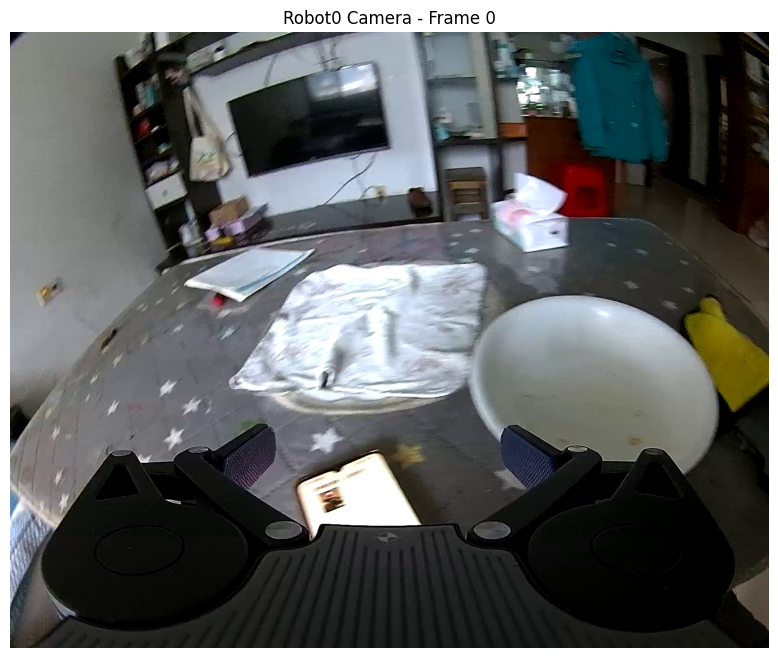

图像尺寸: (1300, 1600, 3)


In [33]:
# 显示第一帧图像
if camera0_data and len(camera0_data) > 0:
    frame_idx = 0
    img_bgr = camera0_data[frame_idx]["decode_data"]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Robot0 Camera - Frame {frame_idx}")
    plt.axis('off')
    plt.show()
    
    print(f"图像尺寸: {img_bgr.shape}")

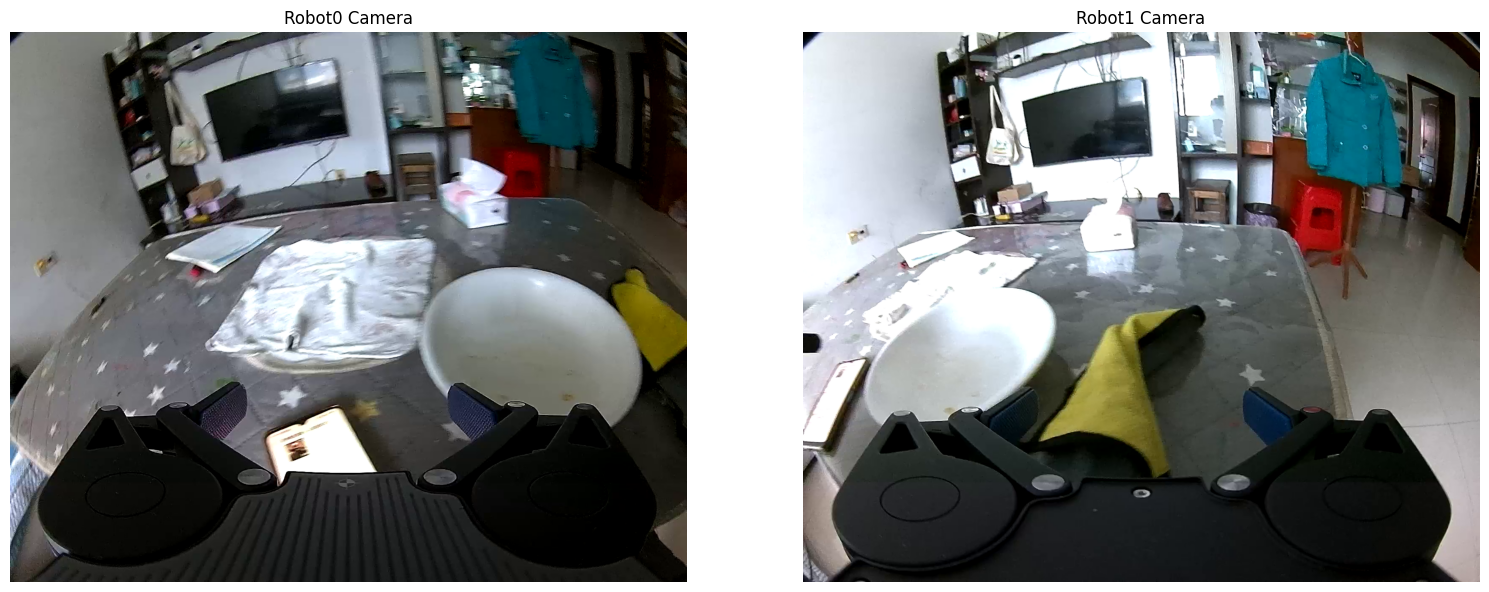

In [32]:
# 显示双机器人对比图
if camera0_data and camera1_data:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    img0_rgb = cv2.cvtColor(camera0_data[0]["decode_data"], cv2.COLOR_BGR2RGB)
    axes[0].imshow(img0_rgb)
    axes[0].set_title("Robot0 Camera")
    axes[0].axis('off')
    
    img1_rgb = cv2.cvtColor(camera1_data[0]["decode_data"], cv2.COLOR_BGR2RGB)
    axes[1].imshow(img1_rgb)
    axes[1].set_title("Robot1 Camera")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## 📈 可视化 VIO 位姿轨迹

In [ ]:
# 提取 VIO 位姿数据 [Pos_X, Pos_Y, Pos_Z, Q_X, Q_Y, Q_Z, Q_W]
if vio0_data:
    positions_0 = np.array([d["decode_data"][:3] for d in vio0_data])
    print(f"Robot0 位姿: {positions_0.shape}")
    print(f"  X: [{positions_0[:,0].min():.3f}, {positions_0[:,0].max():.3f}]")
    print(f"  Y: [{positions_0[:,1].min():.3f}, {positions_0[:,1].max():.3f}]")
    print(f"  Z: [{positions_0[:,2].min():.3f}, {positions_0[:,2].max():.3f}]")

if vio1_data:
    positions_1 = np.array([d["decode_data"][:3] for d in vio1_data])
    print(f"\nRobot1 位姿: {positions_1.shape}")
    print(f"  X: [{positions_1[:,0].min():.3f}, {positions_1[:,0].max():.3f}]")
    print(f"  Y: [{positions_1[:,1].min():.3f}, {positions_1[:,1].max():.3f}]")
    print(f"  Z: [{positions_1[:,2].min():.3f}, {positions_1[:,2].max():.3f}]")

In [ ]:
# 绘制 3D 轨迹
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

if vio0_data:
    ax.plot(positions_0[:,0], positions_0[:,1], positions_0[:,2], 
            label='Robot0', color='blue', linewidth=1.5)
    ax.scatter(positions_0[0,0], positions_0[0,1], positions_0[0,2], 
               color='green', s=100, marker='o', label='Start')
    ax.scatter(positions_0[-1,0], positions_0[-1,1], positions_0[-1,2], 
               color='red', s=100, marker='x', label='End')

if vio1_data:
    ax.plot(positions_1[:,0], positions_1[:,1], positions_1[:,2], 
            label='Robot1', color='orange', linewidth=1.5)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('End-Effector 3D 轨迹')
ax.legend()
plt.show()

In [ ]:
# 绘制 XYZ 位置随时间变化
if vio0_data:
    timestamps_0 = np.array([d["data"].header.timestamp for d in vio0_data])
    t_0 = (timestamps_0 - timestamps_0[0]) / 1e9
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    for i, (label, color) in enumerate(zip(['X', 'Y', 'Z'], ['red', 'green', 'blue'])):
        axes[i].plot(t_0, positions_0[:,i], color=color, linewidth=1)
        axes[i].set_ylabel(f'{label} (m)')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_title(f'Robot0 End-Effector {label} Position')
    
    axes[2].set_xlabel('时间 (秒)')
    plt.tight_layout()
    plt.show()

## 🎬 生成视频

In [ ]:
# 保存 robot0 相机视频
if camera0_data:
    output_path = "robot0_camera.mp4"
    fps = 30
    sample_img = camera0_data[0]["decode_data"]
    h, w = sample_img.shape[:2]
    new_h, new_w = h // 4, w // 4
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    video_writer = cv2.VideoWriter(output_path, fourcc, fps, (new_w, new_h))
    
    for d in camera0_data:
        img = cv2.resize(d["decode_data"], (new_w, new_h))
        video_writer.write(img)
    
    video_writer.release()
    print(f"视频已保存: {output_path}")
    print(f"分辨率: {new_w}x{new_h}, 帧数: {len(camera0_data)}, FPS: {fps}")

In [ ]:
# 在 notebook 中播放视频
Video("robot0_camera.mp4", embed=True, width=640)

## 🔍 查看原始数据样本

In [ ]:
# 查看单帧数据结构
if camera0_data:
    sample = camera0_data[0]
    print("🖼️ camera0/compressed:")
    print(f"  shape: {sample['decode_data'].shape}, dtype: {sample['decode_data'].dtype}")
    print(f"  timestamp: {sample['data'].header.timestamp}")

if vio0_data:
    sample = vio0_data[0]
    print("\n📍 vio/eef_pose:")
    print(f"  data: {sample['decode_data']}")
    print(f"  位置 (x,y,z): {sample['decode_data'][:3]}")
    print(f"  四元数 (qx,qy,qz,qw): {sample['decode_data'][3:]}")

if imu0_data:
    sample = imu0_data[0]
    print("\n📊 imu:")
    print(f"  data: {sample['decode_data']}")
    
if encoder0_data:
    sample = encoder0_data[0]
    print("\n🧲 magnetic_encoder:")
    print(f"  data: {sample['decode_data']}")